In [2]:
import logging
logging.basicConfig(level=logging.WARNING)
root_logger = logging.getLogger()
root_logger.setLevel(logging.WARNING)
for name in ("transformers", "tokenizers", "torch"):
    logging.getLogger(name).setLevel(logging.WARNING)

import torch
import torch.nn as nn
import json
import os
import pandas as pd
from models.lstm_proj_diff import LSTM as LSTM2
from models.transformer import Transformer
from utils.dataset import TranslateDataset
from torch.utils.data import DataLoader
import tokenizers
import numpy as np
from tqdm import tqdm

In [3]:
np.exp(1.59)

np.float64(4.903748928326623)

In [4]:
df_eval = pd.read_parquet("data/tokenized_test.parquet").sample(frac=0.1, random_state=42).reset_index(drop=True)
# df_train = pd.read_parquet("data/tokenized_train.parquet").sample(n=100, random_state=42).reset_index(drop=True)

In [5]:
tokenizer = tokenizers.Tokenizer.from_file("artifacts/tokenizer_50000.json")

In [6]:
dataset_eval = TranslateDataset(
    tokens_src=df_eval['en_tokens_50000'].tolist(),
    tokens_tgt=df_eval['pt_tokens_50000'].tolist(),
    invert_src=False,
    max_len=30
)

dataloader_eval = DataLoader(dataset_eval, batch_size=64, shuffle=False)

In [7]:
MODELS_TRY = [
    LSTM2
]

In [10]:
PATH_MODELS = "artifacts"

models = {}
for file in os.listdir(PATH_MODELS):
    if file.endswith(".pt"):
        model_name = file.split(".")[0].replace('model_', '')
        # keep only models with version >= 47
        try:
            ver = int(model_name.lstrip('v')) if model_name.startswith('v') else None
        except ValueError:
            ver = None
        if ver is None or ver not in (50, 56, 62):
            continue
        print(f'Lendo {model_name}')
        model_path = os.path.join(PATH_MODELS, file)
        model_config_path = os.path.join("configs", f"{model_name}_config.json")
        
        with open(model_config_path, 'r', encoding='utf-8') as f:
            model_config = json.load(f)
        
        if 'architecture' in model_config and model_config['architecture'] == 'transformer':
            model = Transformer(
                embedding_dim=model_config["embedding_dim"],
                encoder_num_layers=model_config["encoder_num_layers"],
                decoder_num_layers=model_config["decoder_num_layers"],
                encoder_hidden_dim=model_config["encoder_hidden_dim"],
                decoder_hidden_dim=model_config["decoder_hidden_dim"],
                encoder_num_heads=model_config["encoder_num_heads"],
                decoder_num_heads=model_config["decoder_num_heads"],
                encoder_dropout=model_config["encoder_dropout"],
                decoder_dropout=model_config["decoder_dropout"],
                vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 50000,
            )
        else:
            model = LSTM2(embedding_dim=model_config["embedding_dim"],
                        encoder_bidirectional=model_config["encoder_bidirectional"],
                        encoder_hidden_dim=model_config["encoder_hidden_dim"],
                        encoder_num_layers=model_config["encoder_num_layers"],
                        decoder_hidden_dim=model_config["decoder_hidden_dim"],
                        decoder_num_layers=model_config["decoder_num_layers"],
                        encoder_dropout=model_config["encoder_dropout"],
                        decoder_dropout=model_config["decoder_dropout"],
                        vocab_size=model_config["vocab_size"] if "vocab_size" in model_config else 10000, 
                        attention = model_config["attention"] if "attention" in model_config else False,
                        pad_idx=0)
            model.load_state_dict(torch.load(model_path))
            model.to("cuda" if torch.cuda.is_available() else "cpu")
            model.eval()
            models[model_name] = model

Lendo v50
Lendo v56
Lendo v62


In [11]:
print(models.keys())

dict_keys(['v50', 'v56'])


In [ ]:
from utils.metrics import compute_bleu, compute_rouge
from torch.nn.utils.rnn import pad_sequence

metrics_by_model = {}
batch_size = 256

for model_name, model in models.items():

    print(f"Model: {model_name}")

    decoded_outputs = []
    reference_texts = []

    device = next(model.parameters()).device

    # Iterar manualmente pelo dataset e aplicar padding por batch
    n = len(dataset_eval)
    for start in tqdm(range(0, n, batch_size)):
        batch_items = [dataset_eval[i] for i in range(start, min(start + batch_size, n))]
        srcs = [item[0] for item in batch_items]
        tgts = [item[1] for item in batch_items]

        srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=0).to(device)
        tgts_padded = pad_sequence(tgts, batch_first=True, padding_value=0).to(device)

        tgt_tokens = tgts_padded[:, 1:]  # Remove o token de início

        # Decode ground-truth references (skip special tokens for metrics)
        reference_texts.extend(
            tokenizer.decode_batch(
                tgt_tokens.cpu().tolist(),
                skip_special_tokens=True
            )
        )

        with torch.no_grad():
            outputs = model.predict(
                src=srcs_padded,
                bos_token_id=5,
                eos_token_id=6,
                max_len=30,
            )

        # Decode predictions (skip special tokens for metrics)
        decoded_outputs.extend(
            tokenizer.decode_batch(
                outputs.cpu().tolist(),
                skip_special_tokens=True
            )
        )

    df_eval[f'{model_name}_pred'] = decoded_outputs

    # Compute metrics using utils/metrics
    try:
        bleu_res = compute_bleu(reference_texts, decoded_outputs)
    except Exception as e:
        bleu_res = {"error": str(e)}
    try:
        rouge_res = compute_rouge(reference_texts, decoded_outputs)
    except Exception as e:
        rouge_res = {"error": str(e)}

    metrics_by_model[model_name] = {"bleu": bleu_res, "rouge": rouge_res}
    print('BLEU:', bleu_res)
    print('ROUGE:', rouge_res)


Model: v50


  0%|          | 0/320 [00:00<?, ?it/s]

 66%|██████▌   | 211/320 [00:25<00:12,  8.49it/s]

In [30]:
import pandas as pd

# Converter dict de métricas para DataFrame (linhas = modelos)
df_metrics = pd.DataFrame.from_dict(metrics_by_model, orient='index')

# Helper seguro para navegar dicionários aninhados
def _safe_get(d, keys, default=None):
    try:
        v = d
        for k in keys:
            if not isinstance(v, dict):
                return default
            v = v.get(k)
        return v
    except Exception:
        return default

# Extrair BLEU (pode ser dict {'bleu': val} ou já um número em casos especiais)
df_metrics['bleu_score'] = df_metrics['bleu'].apply(lambda b: b.get('bleu') if isinstance(b, dict) and 'bleu' in b else (b if isinstance(b, (int, float)) else None))

# Extrair todas as subcolunas do ROUGE (rouge1, rouge2, rougeL)
for r in ['rouge1', 'rouge2', 'rougeL']:
    for m in ['precision', 'recall', 'fmeasure']:
        df_metrics[f'{r}_{m}'] = df_metrics['rouge'].apply(lambda x: _safe_get(x, [r, m]))

# Perplexity (já deve ser numérico) e limpeza básica
df_metrics['perplexity'] = df_metrics.get('perplexity').apply(lambda x: float(x) if x is not None else None) if 'perplexity' in df_metrics.columns else None

# Coluna auxiliar com recall do rouge2 para ordenação
df_metrics['rouge2_recall'] = df_metrics['rouge2_recall'] if 'rouge2_recall' in df_metrics.columns else df_metrics['rouge'].apply(lambda x: _safe_get(x, ['rouge2', 'recall']))

# Ordenar decrescentemente por recall do rouge2
df_metrics_sorted = df_metrics.sort_values('rouge2_recall', ascending=False)

df_metrics_sorted

,bleu,rouge,bleu_score,rouge1_precision,rouge1_recall,rouge1_fmeasure,rouge2_precision,rouge2_recall,rouge2_fmeasure,rougeL_precision,rougeL_recall,rougeL_fmeasure,perplexity
v55,{'bleu': 18.088347844028565},"{'rouge1': {'precision': 0.43578777737560187, ...",18.088348,0.435788,0.669214,0.521751,0.282854,0.461185,0.345077,0.422805,0.650334,0.506523,None
v50,{'bleu': 19.010317230227376},"{'rouge1': {'precision': 0.6330202488921726, '...",19.010317,0.633020,0.624652,0.625613,0.412066,0.407027,0.407192,0.621139,0.612976,0.613906,None
v56,{'bleu': 6.9435934049766805},"{'rouge1': {'precision': 0.4812917735539246, '...",6.943593,0.481292,0.257899,0.330761,0.238061,0.112330,0.149416,0.471438,0.252676,0.324013,None
v47,{'bleu': 3.3314332165427616},"{'rouge1': {'precision': 0.2191440438140763, '...",3.331433,0.219144,0.294671,0.248673,0.076702,0.105041,0.087532,0.207486,0.279533,0.235606,None
v48,{'bleu': 2.963896601077532},"{'rouge1': {'precision': 0.2970131720256239, '...",2.963897,0.297013,0.195697,0.231340,0.111159,0.070599,0.084244,0.285480,0.188814,0.222853,None
v49,{'bleu': 0.9408192692690713},"{'rouge1': {'precision': 0.3870421856108556, '...",0.940819,0.387042,0.120083,0.178945,0.081044,0.023247,0.035270,0.378631,0.117233,0.174741,None


In [31]:
df_configs = pd.DataFrame([json.load(open(os.path.join("configs", f))) for f in os.listdir("configs") if f.endswith("_config.json")])
df_configs = df_configs.loc[df_configs['name'].isin(models.keys())].sort_values(by='name', ascending=False)
df_configs = df_configs[['name'] + df_configs.columns.tolist()]
df_configs

,name,invert_src,embedding_dim,encoder_hidden_dim,decoder_hidden_dim,encoder_num_layers,decoder_num_layers,encoder_dropout,decoder_dropout,encoder_bidirectional,...,max_len,clip_grad,init_weight_method,init_bias_method,teacher_forcing,scheduler_sampling,teacher_forcing_ratio,max_steps_scheduler_sampling,curriculum_levels,attention
46,v56,False,384,1024,1024,3,3,0.1,0.1,True,...,30.0,1.5,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 100000, 'max_len': 10, 'batch_si...",True
45,v55,False,384,512,512,1,1,0.1,0.1,True,...,30.0,NaN,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 500000, 'max_len': 30, 'batch_si...",True
40,v50,False,384,1024,1024,3,3,0.4,0.4,True,...,30.0,1.5,xavier_uniform,zeros,True,True,1.0,200000.0,"[{'max_step': 40000, 'max_len': 10, 'batch_siz...",NaN
38,v49,False,384,1024,1024,3,3,0.4,0.4,True,...,30.0,1.5,xavier_uniform,zeros,True,True,1.0,40000.0,"[{'max_step': 80000, 'max_len': 10, 'batch_siz...",NaN
37,v48,False,384,1024,1024,3,3,0.4,0.4,True,...,30.0,1.5,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 80000, 'max_len': 10, 'batch_siz...",NaN
36,v47,False,384,1024,1024,3,3,0.4,0.4,True,...,30.0,1.5,xavier_uniform,zeros,True,False,1.0,50000.0,"[{'max_step': 500000, 'max_len': 30, 'batch_si...",NaN


In [32]:
df_configs.to_dict(orient='records')

/tmp/ipykernel_20351/2668726291.py:1: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  df_configs.to_dict(orient='records')


[{'name': 'v56',
  'invert_src': False,
  'embedding_dim': 384,
  'encoder_hidden_dim': 1024,
  'decoder_hidden_dim': 1024,
  'encoder_num_layers': 3,
  'decoder_num_layers': 3,
  'encoder_dropout': 0.1,
  'decoder_dropout': 0.1,
  'encoder_bidirectional': True,
  'batch_size': 384,
  'accum_steps': 1,
  'log_steps': 250,
  'save_steps': 1000,
  'eval_steps': 500,
  'device': 'cuda',
  'desc': 'Subindo a dimensão da camada oculta e aplicando curriculum learning',
  'early_stop_patience': 100,
  'early_stop_min_delta': 0.0,
  'warmup_steps': 1000.0,
  'max_steps': 500000.0,
  'learning_rate': 0.0001,
  'vocab_size': 50000.0,
  'max_len': 30.0,
  'clip_grad': 1.5,
  'init_weight_method': 'xavier_uniform',
  'init_bias_method': 'zeros',
  'teacher_forcing': True,
  'scheduler_sampling': False,
  'teacher_forcing_ratio': 1.0,
  'max_steps_scheduler_sampling': 50000.0,
  'curriculum_levels': [{'max_step': 100000,
    'max_len': 10,
    'batch_size': 1024,
    'accum_steps': 1},
   {'max_ste

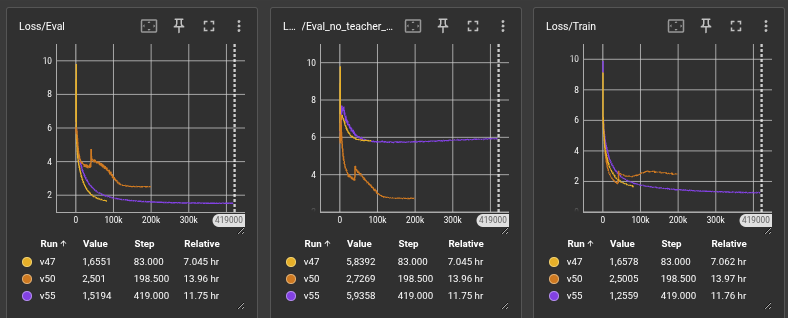

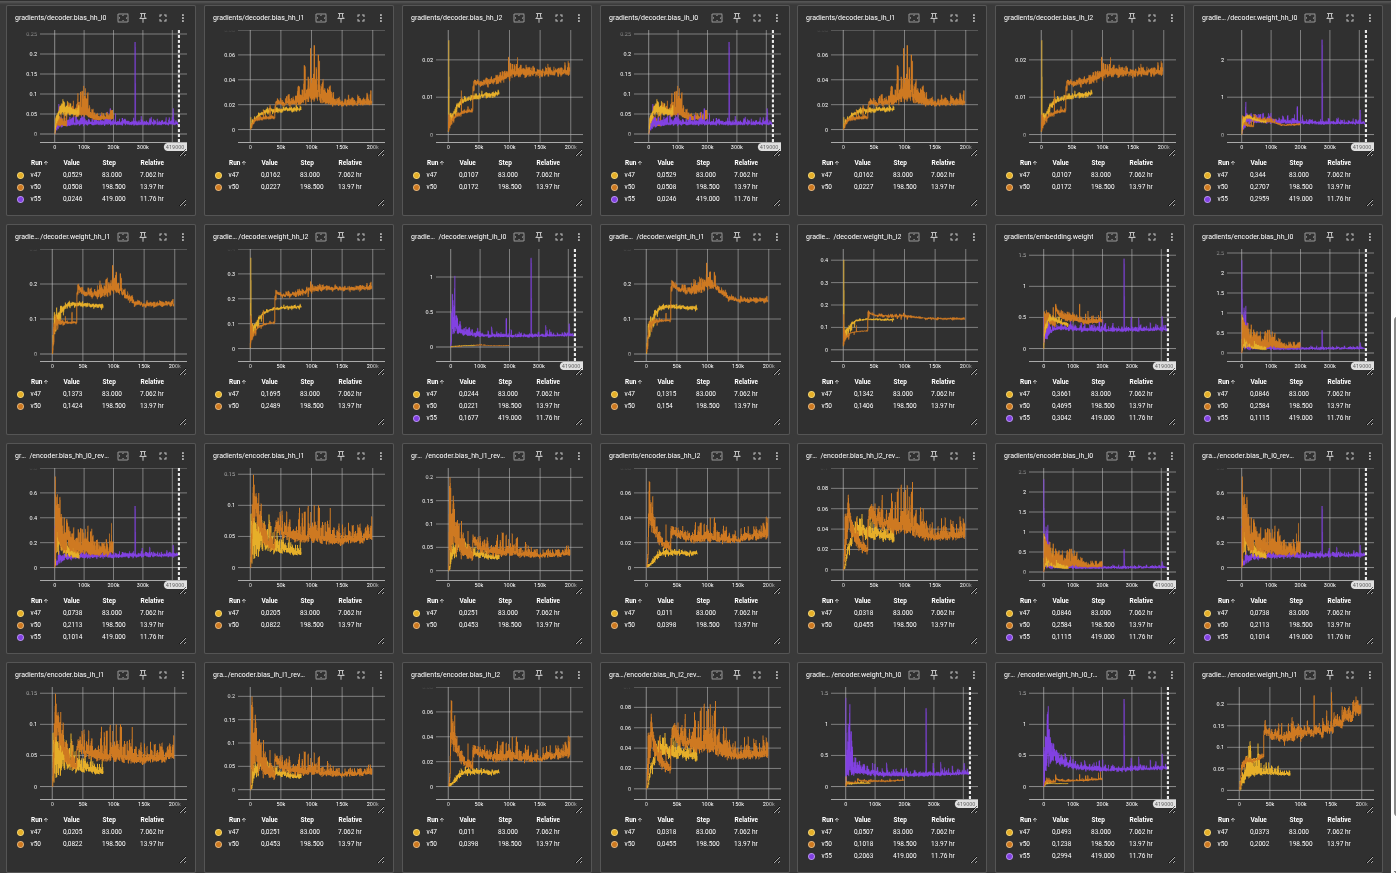

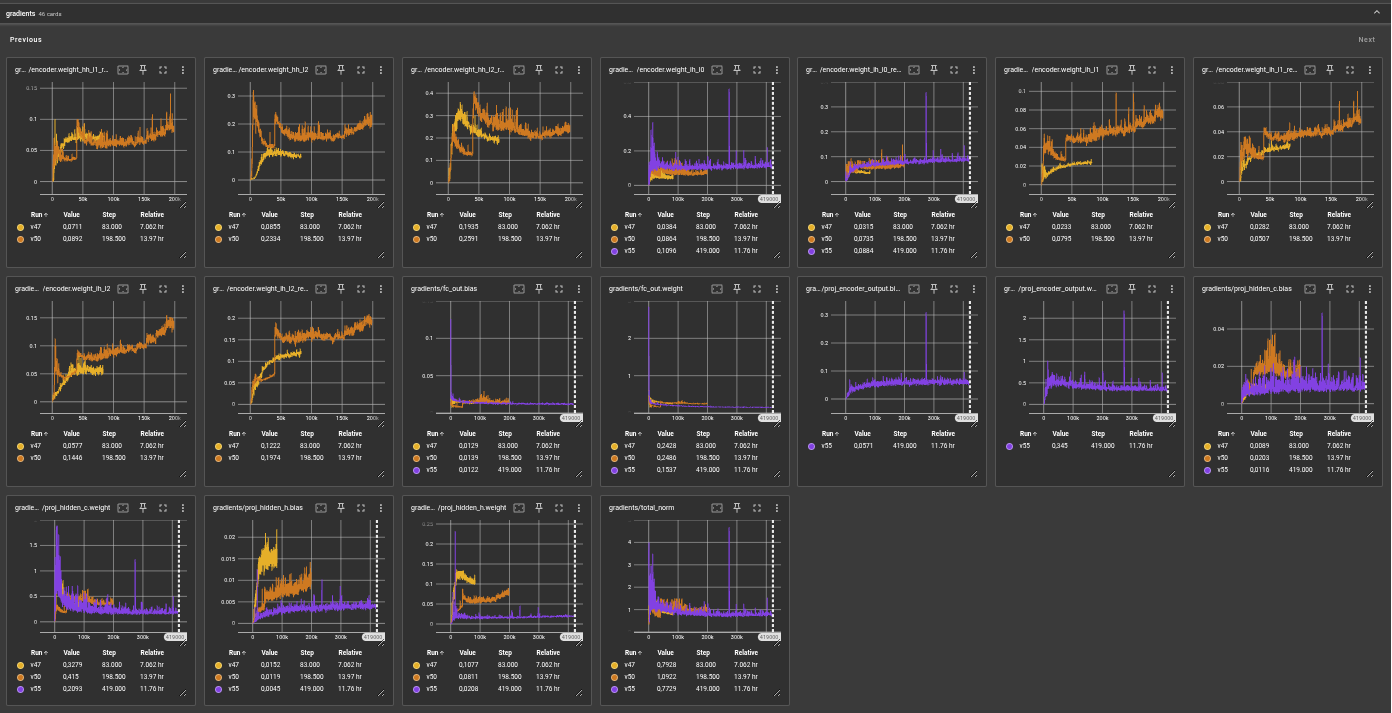

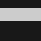

In [33]:
for index in np.random.choice(len(df_eval), size=100, replace=False):
    print('Inglês:', df_eval['en'].iloc[index])
    print('Português:', df_eval['pt'].iloc[index])
    for column in df_eval.columns:
        if('_pred' in column):
            model_test = column
            print(f'{model_test}:', df_eval[model_test].iloc[index])
    print('-'*200)

Inglês: Peter, do me a favour and look in on lauren and sophy.
Português: Peter, me faça o favor de vigiar a lauren e a sophy.
v47_pred: Peter , faça um favor para mim e ligar para a casa de que você e eu sou o mesmo . . .
v48_pred: - peter , faça um bom , roddy . . . . . . . . ! ! !
v49_pred: Peter , com um ! ! !
v50_pred: Peter , me - me um favor e olhe para lauren e sophy . .
v55_pred: Peter , faça - me um favor e olhe para a lauren e sophy . em . ai
v56_pred: Peter , me faça um favor . . .
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Inglês: And rule number two, i want to speak to my daughter now.
Português: E regra número dois, quero falar com a minha filha.
v47_pred: E o número dois , precisamos falar com a filha de minha filha agora . . . . . .
v48_pred: Que regra número , temos que ser . . .
v49_pred: E a que a . . .
v50_pre